In [ ]:
plt.axhline(1.0, color="red", ls="--")
plt.axvline(0.7, color="blue", ls="--")

# get current x-axis maximum
ax = plt.gca()

# Get current axis limits
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# Selection thresholds
xcut = 0.7   # z - Y
ycut = 1.0   # i - z

In [23]:
import numpy as np
from astropy.io import ascii
from astropy.coordinates import SkyCoord
from astropy import units as u

# Paths to your files
catalog_file = "/Users/aishwarya/Documents/Lyman_alpha/LBG_candidates_ZY.cat"
coord_file = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"
output_file = "/Users/aishwarya/Desktop/CSV/Matched_candidates_withmags.cat"

# Load the catalog
catalog = ascii.read(catalog_file)

# Assuming your catalog has 'RA' and 'DEC' columns (in degrees)
cat_coords = SkyCoord(ra=catalog['RA']*u.deg, dec=catalog['DEC']*u.deg)

# Load the RA/DEC list
coords_list = np.loadtxt(coord_file)  # assumes 2 columns: RA DEC in degrees
ra_list, dec_list = coords_list[:,0], coords_list[:,1]
target_coords = SkyCoord(ra=ra_list*u.deg, dec=dec_list*u.deg)

# Match coordinates within a small tolerance (e.g., 1 arcsec)
idx, d2d, _ = target_coords.match_to_catalog_sky(cat_coords)
max_sep = 1.0 * u.arcsec
matches = d2d < max_sep

# Extract matched rows
matched_rows = catalog[idx[matches]]

# Save matched rows
ascii.write(matched_rows, output_file, overwrite=True)

# Print summary
print(f"Found {len(matched_rows)} matches. Saved to {output_file}")

# Print coordinates that did not match
unmatched_coords = coords_list[~matches]
print(f"Number of sources not matched: {len(unmatched_coords)}")
print("Coordinates not matched (RA DEC):")
for ra, dec in unmatched_coords:
    print(f"{ra:.8f} {dec:.8f}")

Found 111 matches. Saved to /Users/aishwarya/Desktop/CSV/Matched_candidates_withmags.cat
Number of sources not matched: 1
Coordinates not matched (RA DEC):
358.19302900 -30.94298720


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_64429/1433591895.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True)


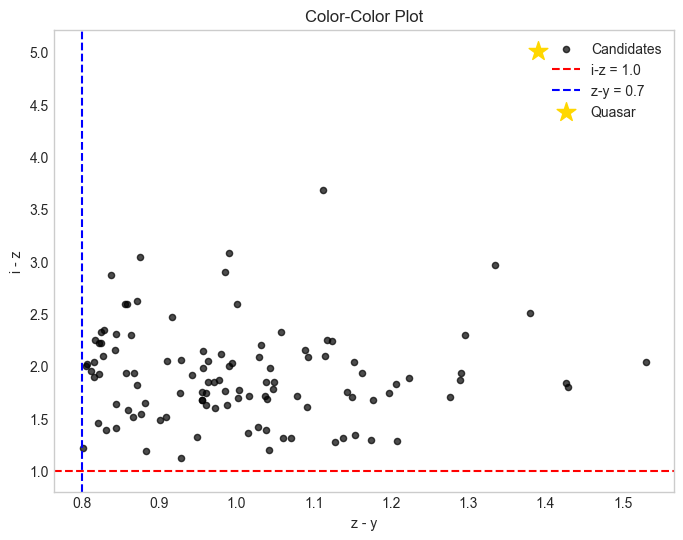

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# File path
file_path = "/Users/aishwarya/Desktop/CSV/Matched_candidates_withmags.cat"

# Load the catalog
data = pd.read_csv(file_path, delim_whitespace=True)

# Set I_mag to limiting magnitude if fainter than 27.46
lim_mag = 27.46
data['I_mag_limited'] = data['I_mag'].copy()
data.loc[data['I_mag'] > lim_mag, 'I_mag_limited'] = lim_mag

# Compute colors using limited I_mag
data['i_z'] = data['I_mag_limited'] - data['Z_mag']
data['z_y'] = data['Z_mag'] - data['Y_mag']

# Plot
plt.figure(figsize=(8,6))
plt.scatter(data['z_y'], data['i_z'], s=20, c='black', alpha=0.7, label='Candidates')

# Plot selection lines
plt.axhline(1.0, color="red", ls="--", label='i-z = 1.0')
plt.axvline(0.8, color="blue", ls="--", label='z-y = 0.7')

# Plot Quasar at its RA/DEC by finding nearest in catalog
RA_QSO = 357.138875
DEC_QSO = -30.9028417

# Find closest match to quasar in catalog
qso = data.iloc[((data['RA'] - RA_QSO)**2 + (data['DEC'] - DEC_QSO)**2).idxmin()]
plt.scatter(qso['z_y'], qso['i_z'], marker='*', s=200, color='gold', label='Quasar')

# Labels and legend
plt.xlabel('z - y')
plt.ylabel('i - z')
plt.title(f'Color-Color Plot')
plt.legend()
plt.grid(False)
plt.show()

/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_64429/2982330173.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True)


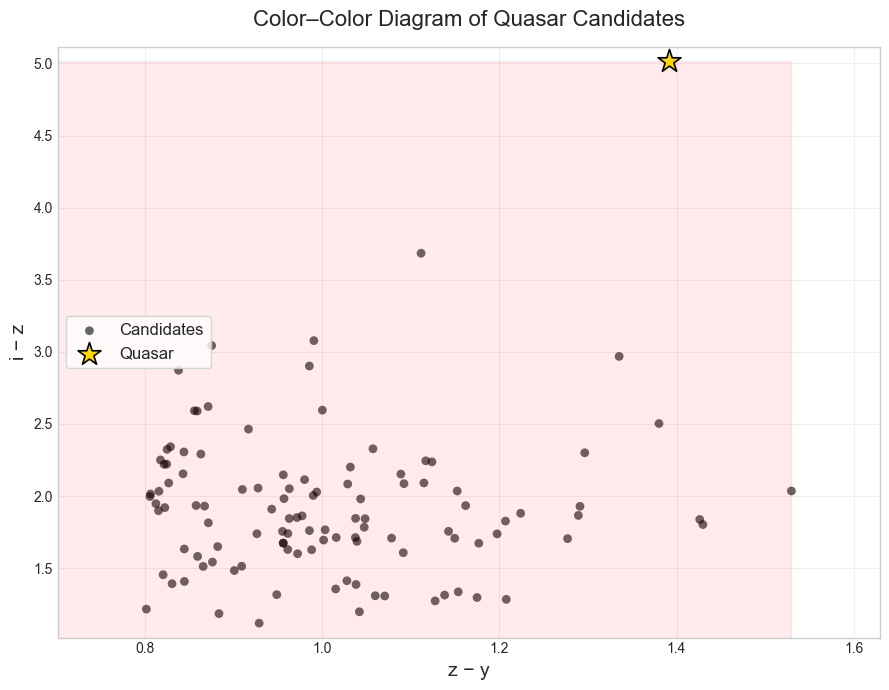

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Load data
# ---------------------------
file_path = "/Users/aishwarya/Desktop/CSV/Matched_candidates_withmags.cat"
data = pd.read_csv(file_path, delim_whitespace=True)

# ---------------------------
# Magnitude limit
# ---------------------------
lim_mag = 27.46
data['I_mag_limited'] = data['I_mag'].clip(upper=lim_mag)

# Compute colors
data['i_z'] = data['I_mag_limited'] - data['Z_mag']
data['z_y'] = data['Z_mag'] - data['Y_mag']

# ---------------------------
# Quasar position
# ---------------------------
RA_QSO = 357.138875
DEC_QSO = -30.9028417

qso = data.iloc[((data['RA'] - RA_QSO)**2 + 
                 (data['DEC'] - DEC_QSO)**2).idxmin()]

# ---------------------------
# Plot styling
# ---------------------------
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(9,7))

# Candidates
plt.scatter(
    data['z_y'],
    data['i_z'],
    s=40,
    color="black",
    alpha=0.6,
    edgecolor='none',
    label="Candidates"
)

# Quasar
plt.scatter(
    qso['z_y'],
    qso['i_z'],
    marker='*',
    s=300,
    color='gold',
    edgecolor='black',
    linewidth=1.2,
    zorder=5,
    label="Quasar"
)

# Selection lines
plt.axhline(1.0, color="red", linestyle="--", linewidth=2)
plt.axvline(0.7, color="blue", linestyle="--", linewidth=2)

# Selection region shading
plt.fill_between(
    [0.7, max(data['z_y'])],
    1.0,
    max(data['i_z']),
    color='red',
    alpha=0.08
)

# Labels
plt.xlabel("z − y", fontsize=14)
plt.ylabel("i − z", fontsize=14)
plt.title("Color–Color Diagram of Quasar Candidates", fontsize=16, pad=15)

# Legend
plt.legend(frameon=True, fontsize=12)

# Limits (optional but clean)
plt.xlim(min(data['z_y'])-0.1, max(data['z_y'])+0.1)
plt.ylim(min(data['i_z'])-0.1, max(data['i_z'])+0.1)

# Grid and layout
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()